# Beispiele

In [21]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

## Beispiel generisch: Eignungstestklassifikation - White Box
<div>
    <img src=attachment:e29f3314-9644-44dd-91cc-e54a5fb5749d.png width=100>
</div>

Wir sind wieder bei unserem Beispiel "Eignungstest - Mini-SVM". Darin war es unsere Aufgabe Ergebnisse von Eignungstests anhand einer SVM klassifizieren zu lassen. Nun würden wir gerne genau sehen können, was unser Machine Learning Modell gelernt hat und __wie__ es Entscheidungen trifft - __White-Box-Modelle__. Hierzu trainieren wir einen kleinen Random Forest `n_estimators=5` auf unsere Daten `X_y` und lassen uns mittels der `plot_tree`-Funktion aus `sklearn` den zweiten Decision Tree des Random Forest visualisieren - und das alles als _One-Liner_.
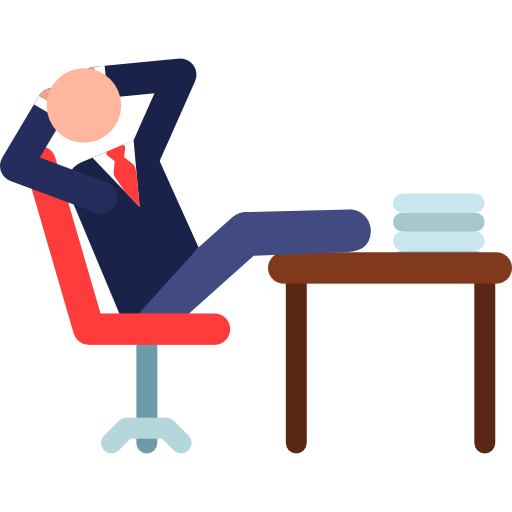

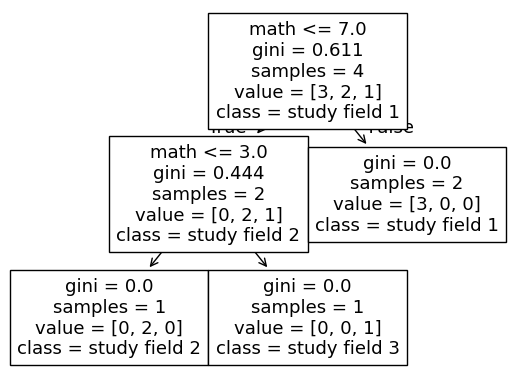

In [3]:
# Your data: student scores in (math, language, creativity) --> study field
X_y = np.array([
    [9, 5, 6, 'study field 1'],
    [10, 1, 2, 'study field 1'],
    [1, 8, 1, 'study field 2'],
    [4, 9, 3, 'study field 2'],
    [0, 1, 10, 'study field 3'],
    [5, 7, 9, 'study field 3'],
])
feature_names = ['math', 'language', 'creativity']
class_names = ['study field 1', 'study field 2', 'study field 3']

# One-liner (Sie dürfen nur in Zeile 16 Code schreiben)
plot_tree(RandomForestClassifier(n_estimators=5).fit(X_y[:, :-1], X_y[:, -1])[0], feature_names=feature_names, class_names=class_names);

## Beispiel spezifisch: Servo Engine Fault Classification

<div>
    <img src=attachment:ddc465b7-cb44-4261-8caa-be23a13a025d.png width=100>
</div>

Stellen Sie sich vor Sie würden in einem Maschinenbauunternehmen arbeiten und Ihnen liegen Sensordaten `(temperature, current)` von 300 Servomotoren einer hochautomatisierten Produktionsanlage vor. Es handelt sich nicht um Zeitseriendaten, sondern um Mittelwerte über jeweils eine Woche. Von jedem Servomotor wissen Sie, ob er sich in einem guten `healthy` , mittleren `do_inspection` oder schlechten `bad` Zustand befunden hat. Aus Erfahrung wissen Sie, dass diese Zustände oft schwierig voneinander zu unterscheiden sind. Dies würden Sie nun gerne quantifizieren und einen Random Forest hierzu auf den Datensatz trainieren. Sie wollen - nach dem Training - die `.predict_proba()`-Methode nutzen, um quantitativ aussagen zu können, wie gut sich diese Klassen wirklich voneinander trennen lassen bzw. wo er sich bei der Trennung am härtersten tut. Visualisieren Sie diese Unsicherheit mittels eines Scatter-Plots, in dem die Datenpunkte hervorgehoben werden, bei denen sich der Random Forest zu weniger als 75% sicher in der Klassifikation ist. Die identifizierten Punkte können nun von Fachexperten neu beurteilt werden.
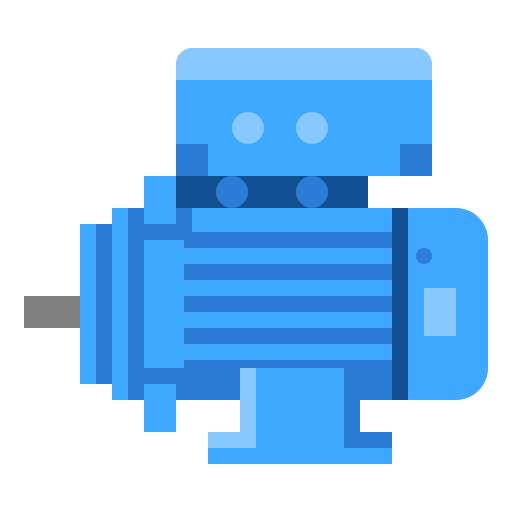

In [7]:
# Split and fit

# Train model

# Calculate class probability

# Histogram of maximum prediction probability

# Visualize most uncertain points in scatter plot


### Generate Data

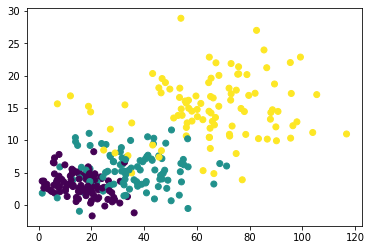

In [4]:
# Data
cluster_std = np.array([1, 1.5, 2.5]) * 1.7
X, y = make_blobs(n_samples=300, n_features=2, centers=[[3, 3], [7, 5], [13, 15]], cluster_std=cluster_std, random_state=22)
X[:, 0] = np.abs(X[:, 0]) * 5 # Temperature
#X[:, 1] = np.abs(X[:, 1]) * 12 # Current

# Look
plt.scatter(X[:, 0], X[:, 1], c=y)

# Save
np.save('./../res/data/servo_engines.npy', np.concatenate((X, y.reshape(-1, 1)), axis=1))

### Lösung

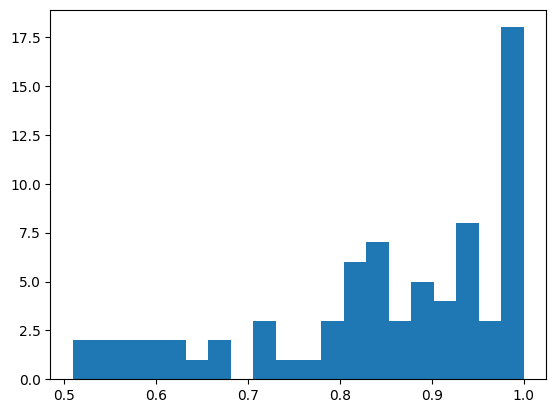

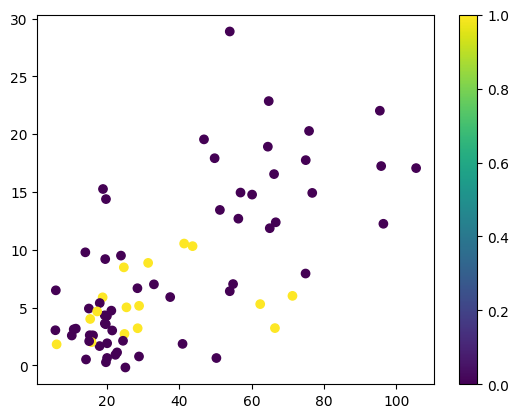

In [2]:
# Load data
X_y = np.load('./../res/data/servo_engines.npy')

# Split and fit
X_train, X_test, y_train, y_test = train_test_split(X_y[:, :-1], X_y[:, -1])
model = RandomForestClassifier(n_estimators=100, random_state=0)

# Train model
model.fit(X_train, y_train)

# Calculate class probability
prediction_probabilities = model.predict_proba(X_test)

# Histogram of maximum prediction probability
max_prediction_probabilities = prediction_probabilities.max(axis=1)
plt.hist(max_prediction_probabilities, bins=20);

# Visualize most uncertain points in scatter plot
plt.figure()
uncertain_data_points = max_prediction_probabilities < 0.75
plt.scatter(X_test[:, 0], X_test[:, 1], c=uncertain_data_points)
plt.colorbar();

## Beispiel spezifisch: Servo Engine Fault Classification - Sensors to roll-out, Sensors to discard

<div>
    <img src=attachment:ea1d268a-d29c-4afe-af1f-676d18ad5245.png width=100>
</div>

Wir bleiben bei unserem vorherigen Servomotorbeispiel. Nun liegen uns neue Messungen derselben Motoren vor - jedoch mit weiteren Sensoren  `(temperature_1, vibration_1, temperature_2, vibration_2, temperature_3, vibration_3, current, rpm)`. Temperatur- und Vibrationssensoren sind an jeweils drei Positionen der Motoren angebracht. Bei den 300 Motoren handelt es sich um eine Stichprobe, anhand derer entschieden werden soll, ob bzw. welche Sensoren in Zukunft an allen Motoren angebracht werden sollen (Sensoren können - vor allem bei großen Stückzahlen - ordentlich "ins Geld gehen"). Als Angestellte im Maschinenbauunternehmen haben Sie nun die Aufgabe mittels dieser Messungen festzustellen, 
1. welche __Sensorenart__ und
1. welche __Sensorenposition__
für die Schadensklassifikation am _wichtigsten_ sind. Darauf aufbauend sollen Sie eine Empfehlung an die Geschäftsleitung geben, welche Sensoren in Zukunft verbaut werden sollen und welche nicht.
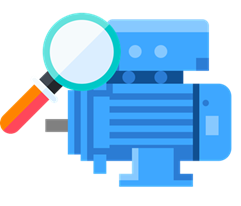

In [6]:
# Split and fit

# Train model

# Permutation importance

# Plot


### Generate Data

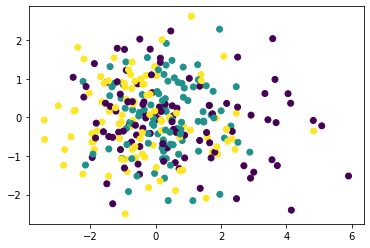

In [7]:
# Data
X, y = make_classification(
    n_samples=300, n_features=8, n_informative=3,
    n_repeated=0, n_classes=3, shuffle=True, random_state=2)

# Look
plt.scatter(X[:, 4], X[:, 5], c=y)

# Save
X_y = np.concatenate((X, y.reshape(-1, 1)), axis=1)
np.save('./../res/data/servo_engines_select_sensors.npy', X_y)

### Lösung

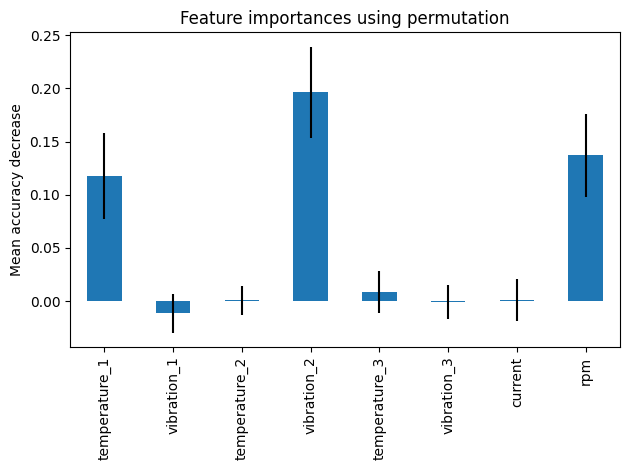

In [3]:
# Load
X_y = np.load('./../res/data/servo_engines_select_sensors.npy')
X = X_y[:, :-1]
y = X_y[:, -1]

# Split and fit
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = RandomForestClassifier(n_estimators=100)

# Train model
model.fit(X_train, y_train)

# Permutation importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=100, n_jobs=-1)
forest_importances = pd.Series(result.importances_mean)

# Plot
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation")
ax.set_ylabel("Mean accuracy decrease")
ax.set_xticklabels(['temperature_1', 'vibration_1', 'temperature_2', 'vibration_2', 'temperature_3', 'vibration_3', 'current', 'rpm'])
fig.tight_layout()
plt.show()

# Large Guided Example: Predictive Maintenance on Turbofan Engines

## Data Ingest
Wir laden die Daten und schauen mal rein.

In [22]:
# read data
train = pd.read_csv('./../res/data/turbo_engine_nasa/X_train.csv')
y_train = pd.read_csv('./../res/data/turbo_engine_nasa/y_train.csv').iloc[:, 0] # Series else warnings pop up 
test = pd.read_csv('./../res/data/turbo_engine_nasa/X_test.csv')
y_test = pd.read_csv('./../res/data/turbo_engine_nasa/y_test.csv').iloc[:, 0] # Series else warnings pop up

# check shape and inspect first few rows
print(train.shape)
train.head()

(24720, 18)


,unit_nr,time_cycles,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,642.36,1583.23,1396.84,21.61,553.97,2387.96,9062.17,1.3,47.30,522.31,2388.01,8145.32,8.4246,391,39.11,23.3537
1,1,2,642.50,1584.69,1396.89,21.61,554.55,2388.00,9061.78,1.3,47.23,522.42,2388.03,8152.85,8.4403,392,38.99,23.4491
2,1,3,642.18,1582.35,1405.61,21.61,554.43,2388.03,9070.23,1.3,47.22,522.03,2388.00,8150.17,8.3901,391,38.85,23.3669
3,1,4,642.92,1585.61,1392.27,21.61,555.21,2388.00,9064.57,1.3,47.24,522.49,2388.08,8146.56,8.3878,392,38.96,23.2951
4,1,5,641.68,1588.63,1397.65,21.61,554.74,2388.04,9076.14,1.3,47.15,522.58,2388.03,8147.80,8.3869,392,39.14,23.4583


<div>
    <img src=attachment:24c0d84d-ce9a-48f3-a397-50dd16ab4378.png width=200>
</div>
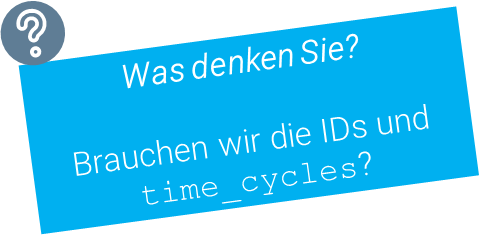

In [24]:
X_train = train.loc[:, 's_2':'s_21']
X_test = test.loc[:, 's_2':'s_21']

## Data Exploration

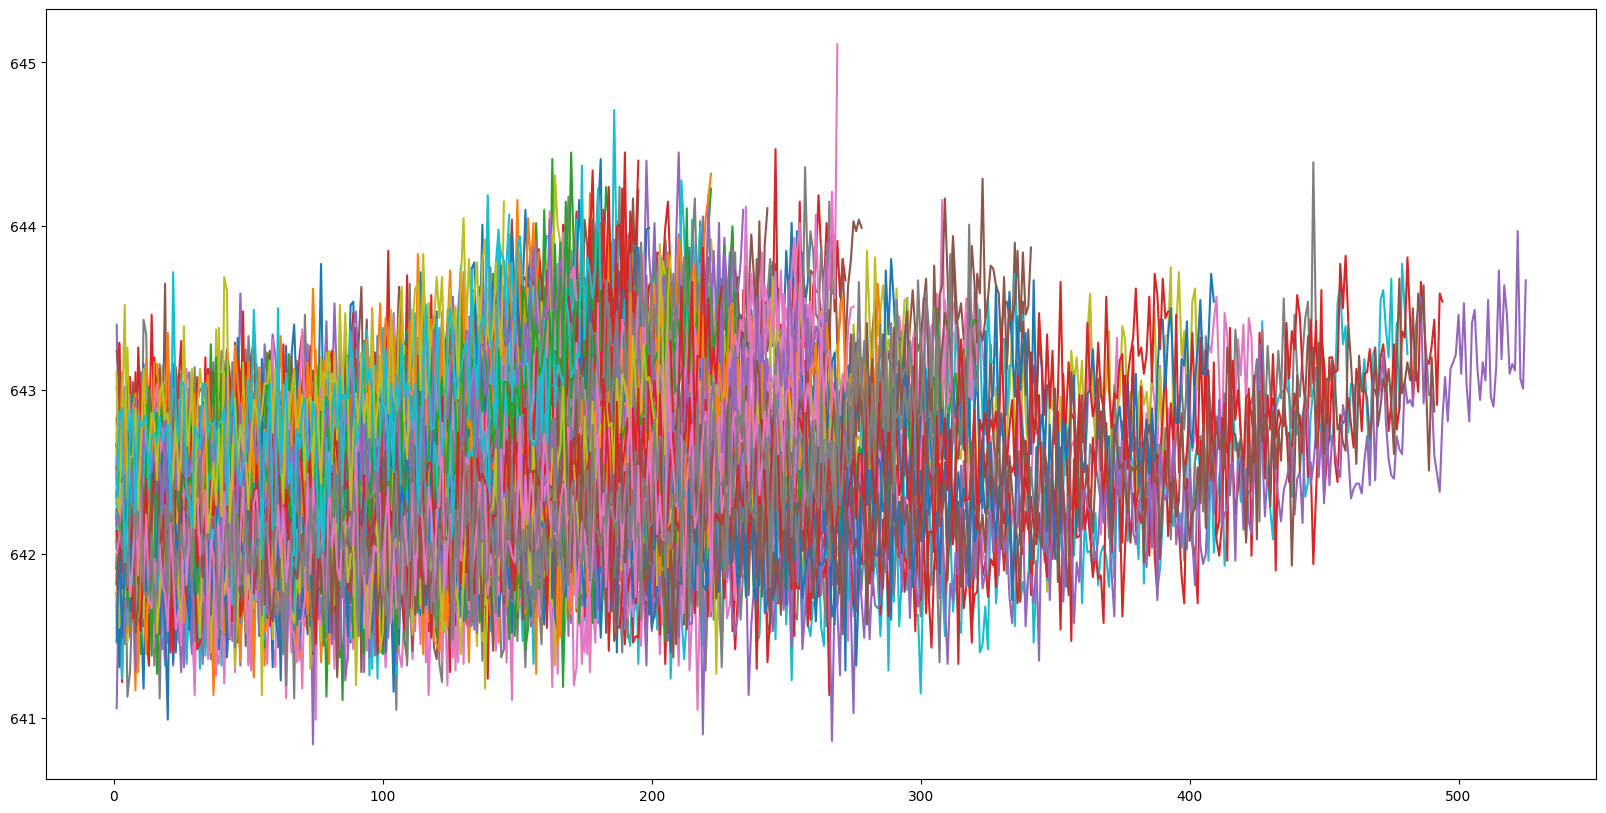

In [25]:
# Look at sensor 2 for all engines
plt.figure(figsize=(20, 10))
for unit_nr in train['unit_nr'].unique():
    sensor_time = train['time_cycles'][train['unit_nr'] == unit_nr]
    sensor_data = train['s_2'][train['unit_nr'] == unit_nr]
    plt.plot(sensor_time, sensor_data)

<div>
    <img src=attachment:8110d51a-8457-4ea0-a6e9-d66e1bd144c6.png width=200>
</div>
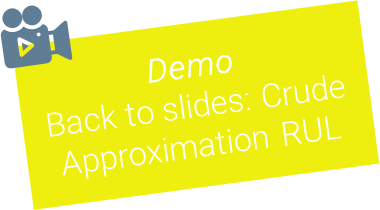

## Baseline Model

Gerne würden wir vergleichen können, wie gut unsere Modelle abschneiden. Wenn keine naive Vorhersage vorliegt, dann nutzt man häufig _Baseline Models_. Hierunter versteht man einfach, nicht so "mächtige", Modelle, die es auf jeden Fall zu "schlagen" gilt.

In [26]:
# Import
from sklearn.linear_model import LinearRegression

# Train
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Evaluate: R**2
print(f'Train set: {lin_reg_model.score(X_train, y_train)}')
print(f'Test set: {lin_reg_model.score(X_test, y_test)}')

Train set: 0.7736110804777435
Test set: 0.7092939799792276


<div>
    <img src=attachment:bf7b7d23-aa6d-4b73-971c-d52185617e37.png width=200>
</div>
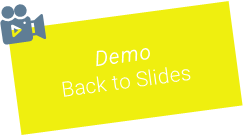

## Random Forest Regressor

### First Trials

In [27]:
# bare random forest regressor: bagging and feature bagging are on
rf = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42)
rf.fit(X_train, y_train)

# predict and evaluate
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9787661901585051
0.7413439613827657


<div>
    <img src=attachment:869cea89-2776-4fb1-8212-1e2d41ba7383.png width=200>
</div>
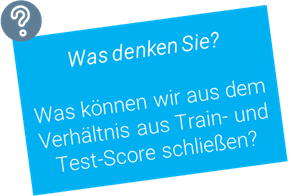

<div>
    <img src=attachment:3442b85c-b890-40e1-8e8f-acc3ebdaa877.png width=250>
</div>

Laut unserer bekannten Grafik aus "Modeling: introduction to Machine Learning" wissen wir, dass eine große Diskrepanz aus Train- und Test-Score auf ein Overfitting hindeutet. Wir überprüfen das anhand einzelner Decision Trees des Random Forest.
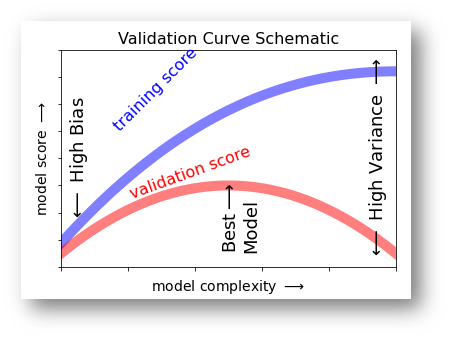

In [28]:
# perform some checks on layout of a SINGLE tree
print(rf.estimators_[5].tree_.max_depth)  # check how many nodes in the longest path
rf.estimators_[5].tree_.n_node_samples    # check how many samples in the last nodes

33


array([15616, 11694,  7793, ...,     1,     1,     4], shape=(17493,))

Wir sehen, dass in den letzten Nodes sehr wenige (einzelne) Datenpunkte vorhanden sind. Die einzelnen Trees "overfitten" sehr stark.

### Investigate overfitting behavior

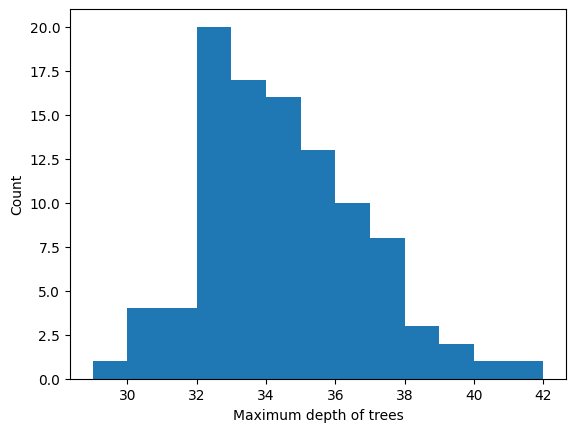

In [29]:
# Plot histogram of maximum depth of trees in forest
max_depths = np.array([estimator_.tree_.max_depth for estimator_ in rf.estimators_])
plt.hist(max_depths, bins=13)
plt.xlabel('Maximum depth of trees')
plt.ylabel('Count');

In [30]:
# Investigate number of samples in nodes: one tree
print(f'This tree has {rf.estimators_[5].tree_.node_count} nodes.')
print(f'and {rf.estimators_[5].tree_.n_node_samples} samples per node.')

This tree has 17493 nodes.
and [15616 11694  7793 ...     1     1     4] samples per node.


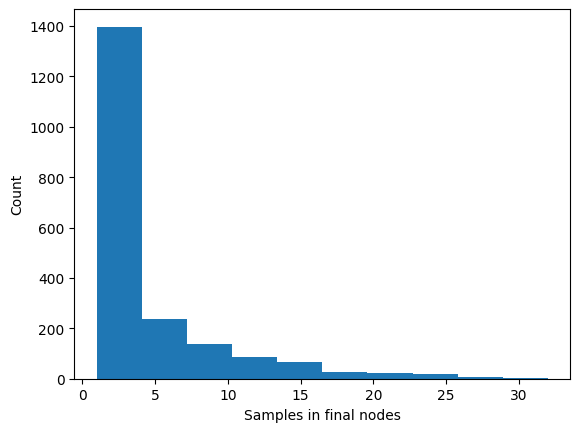

In [31]:
# Investigate number of samples in final nodes: all trees
n_node_samples = np.array([estimator_.tree_.n_node_samples[-20:] for estimator_ in rf.estimators_])
plt.hist(n_node_samples.flat)
plt.xlabel('Samples in final nodes')
plt.ylabel('Count');

<div>
    <img src=attachment:a9c2a125-bb03-4bb7-8f45-e006f72900f7.png width=200>
</div>
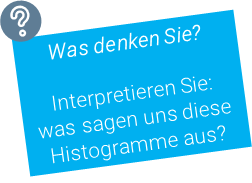

Die Trees tendieren also zum Overfitting. Das wissen wir: Decision Trees haben grundsätzlich diese Tendenz. Aber vielleicht können wir doch noch was rausholen, wenn wir dieses extreme Overfitting wie hier ein wenig "zähmen". Was ändern wir also?

In [32]:
# Tweaked random forest
rf = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42, 
                           max_depth=8, min_samples_leaf=50)
rf.fit(X_train, y_train)

# predict and evaluate
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.8505294865338602
0.7427702419664686


<div>
    <img src=attachment:0210a0fa-e997-457f-b5a5-3f0a6d6d8140.png width=250>
</div>

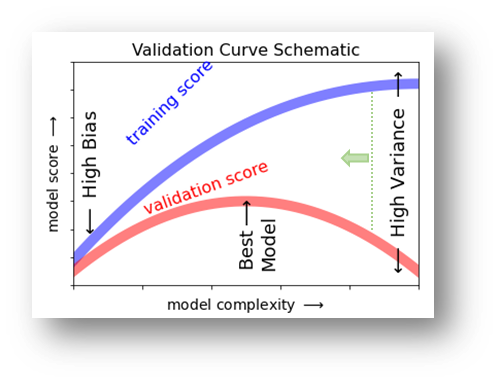

<div>
    <img src=attachment:a8bd4c12-0c02-4af3-8f2d-45b8e63e2866.png width=200>
</div>
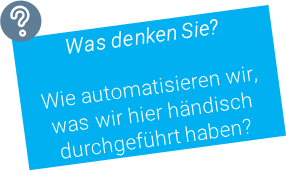

### Hyperparameter Tuning: Sophisticated Guesses
Bisher haben wir Hyperparameter-Sweeps eher so $\pi$-mal-Daumen gemacht. In diesem Abschnitt beschäftigen wir uns damit, ob man auch irgendwie geleitete, informierte, sinnvolle Ranges vorgeben kann - sog. _Sophisticated Guesses_

In [33]:
# Let's look at our possible tuning parameters
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 8,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 50,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

<div>
    <img src=attachment:f7d541ce-a6cf-4851-a821-f60e22933f92.png width=200>
</div>
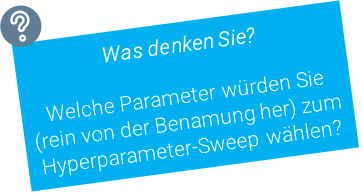

Hyperparameter, die uns beim Bias-Variance-Tradeoff helfen könnten: `max_depth`, `mins_samples_leaf`, `ccp_alpha`, `min_impurity_decrease`. Erinnern Sie sich an die Vorlesung: `n_estimators` hilft uns bzgl. Overfitting nicht so viel - die anderen Aspekte der Trees müssen untersucht werden. `max_depth` und `mins_samples_leaf` sind naheliegend. Im Folgenden beschäftigen wir uns beispielhaft mit _Sophisticated Guesses_ der Hyperparameter-Range von `min_impurity_decrease`.

`ccp_alpha` ist ein weiterer Hyperparameter, der uns bei der Vermeidung von Overfitting hilft. Wir lassen ihn jedoch aus Zeitgründen außen vor und begnügen uns mit einer gegebenen Range. Zur Info:

_"Cost complexity pruning alpha is a parameter used for pruning trees. Pruning is the removal of nodes after fitting, so essentially `ccp_alpha` is an alternative to using `min_samples_leaf` and `max_depth` to prevent overfitting."_

`min_impurity_decrease` bezeichnet die Reduktion der Gini-Impurity nach einem Split. Wie war das nochmal mit der Gini-Impurity und wie könnte man die Verringerung pro Split berechnen?

$$ \frac{N_p}{N}\left(G_p - G_{c}^{left}\frac{N_{left}}{N_p} - G_{c}^{right}\frac{N_{left}}{N_p}\right)$$

Der Hyperparameter `min_impurity_decrease` gibt also an, welche Verringerung der Gini Impurity __mindestens__ pro Split erzeugt werden muss, damit man diesen Split wirklich durchführt. Eine Beschränkung dieses Wertes führt also ganz natürlich zu einer Vermeidung von Overfitting. Wie können wir also nun auf eine geeignete Hyperparameter-Range schließen?

In [35]:
# Info about one decision tree
rf_dict = {
    'id_node': list(range(rf.estimators_[5].tree_.node_count)),
    'impurity': rf.estimators_[5].tree_.impurity,
    'samples': rf.estimators_[5].tree_.n_node_samples,
    'id_left_child': rf.estimators_[5].tree_.children_left,
    'id_right_child': rf.estimators_[5].tree_.children_right
}

impurity_df = pd.DataFrame(rf_dict)
impurity_df.head(10)

,id_node,impurity,samples,id_left_child,id_right_child
0,0,1644.689840,15616,1,128
1,1,609.414829,11694,2,71
2,2,247.609863,7793,3,52
3,3,156.037153,6372,4,29
4,4,97.827624,4473,5,20
5,5,19.630575,1627,6,13
6,6,3.844416,765,7,10
7,7,10.192376,257,8,9
8,8,1.085113,143,-1,-1
9,9,21.980353,114,-1,-1


<div>
    <img src=attachment:1d10f9d8-3df0-4a79-bb08-4aa4bc52a92a.png width=200>
</div>
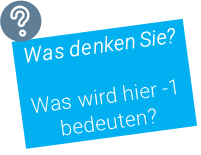

$$ \frac{N_p}{N}\left(G_p - G_{c}^{left}\frac{N_{left}}{N_p} - G_{c}^{right}\frac{N_{left}}{N_p}\right)$$

In [37]:
# Calculate impurity decreases of this single tree
impurity_df['impurity_decrease'] = np.nan
samples_total = rf.estimators_[5].tree_.node_count

for idx in impurity_df.index[1:]:  # skip the first node, there aren't any splits prior to it
    if impurity_df.iloc[idx]['id_left_child'] == -1:
        continue  # we can't calculeate impurity decrease for leave nodes, as they no longer split
    else:
        impurity_P, samples_P = impurity_df.iloc[idx][['impurity', 'samples']]
        id_L, id_R = impurity_df.iloc[idx][['id_left_child', 'id_right_child']].astype(int)
        impurity_L, samples_L = impurity_df.iloc[id_L][['impurity', 'samples']]
        impurity_R, samples_R = impurity_df.iloc[id_R][['impurity', 'samples']]
        
        impurity_decrease = samples_P / samples_total * (
            impurity_P - samples_R / samples_P * impurity_R - 
            samples_L / samples_P * impurity_L
            )
        impurity_df.at[idx, 'impurity_decrease'] = impurity_decrease

In [38]:
impurity_df

,id_node,impurity,samples,id_left_child,id_right_child,impurity_decrease
0,0,1644.689840,15616,1,128,NaN
1,1,609.414829,11694,2,71,6523.487359
2,2,247.609863,7793,3,52,667.339752
3,3,156.037153,6372,4,29,142.951197
4,4,97.827624,4473,5,20,51.746672
...,...,...,...,...,...,...
222,222,40.121345,78,-1,-1,NaN
223,223,18.337871,96,-1,-1,NaN
224,224,11.125188,164,225,226,1.870917
225,225,11.097891,80,-1,-1,NaN


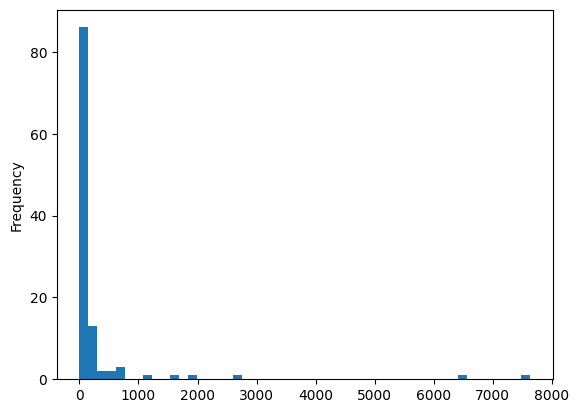

In [39]:
impurity_df['impurity_decrease'].plot(kind='hist', bins=50);

In [40]:
impurity_df[['impurity_decrease']].describe()

,impurity_decrease
count,112.000000
mean,282.515265
std,994.407842
min,-0.506232
25%,14.589094
50%,47.024819
75%,129.095879
max,7639.300570


Wie könnten wir diese Verteilung beschreiben?

* Sie ist sehr rechts-schief
* 25% der Werte liegen bei $\leq 14.59$

&rarr; die großen Verringerungen in der Gini Impurity erreichen die ersten Splits. Je tiefer man in den Baum vordringt, desto weniger `impurity_decrease` erreicht man. Mit dem Wert des Hyperparameters `min_impurity_decrease` entscheidet man also wie viele Nodes man "wegschmeisst". Wir motivieren unsere Grenze dieses Hyperparameters durch unsere Explorationen: wir lassen zu, dass max. 25% der Nodes verworfen werden bzw. nicht mehr gesplittet werden - bis zu diesem Bereich wollen wir den Hyperparameterraum untersuchen. Wir gehen davon aus, dass mehr als 25% zu viel wären und wir evtl. dann schon wieder ins Underfitting kommen würden. Wir wählen das untere Quartil als Grenze unserer Hyperparameter-Range.

In [41]:
# Parameter ranges
list_max_depth = [None] + list(range(3, 34, 3))  # Mode of max_depth of the corresponding histogram was 33
list_min_samples_leaf = list(range(1, 102, 10))  # Manual tweaking was 50 - we double it
list_min_impurity_decrease = list(np.arange(0, 147) / 10)  
list_ccp_alpha = list(np.round(np.linspace(0, 2, 81), decimals=3)) # We take this for granted

# Parameters dict
parameters = {
    'max_depth': list_max_depth,
    'min_samples_leaf': list_min_samples_leaf,
    'min_impurity_decrease': list_min_impurity_decrease,
    'ccp_alpha': list_ccp_alpha
}

# Feasible?
tuning_options = len(list_max_depth) * len(list_min_samples_leaf) * len(list_min_impurity_decrease) * len(list_ccp_alpha)
print(f'We have to train {tuning_options} forests.')

We have to train 1571724 forests.


<div>
    <img src=attachment:bf7b7d23-aa6d-4b73-971c-d52185617e37.png width=200>
</div>
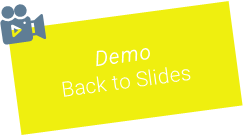

<div>
    <img src=attachment:3294245b-ad5a-4a86-b650-6e544357bd33.png width=200>
</div>
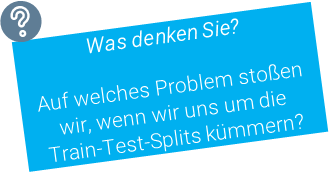

Unser Ziel ist es ein Machine Learning Modell zu erzeugen, das auf _ungesehene_ Motoren generalisieren kann. Wenn wir einen typischen Train-Test-Split mit Cross Validation durchführen, dann kann es passieren, dass in den Trainings- und Validation-Folds Daten ein und desselben Motors vorhanden sind. Dies gilt es zu vermeiden. Hierzu verwenden wir `GroupKFold`. Daraus gewinnen wir einen  _CV-Generator_.

In [42]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
rf = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42)
gkf = GroupKFold(n_splits=3)

Dieser CV-Generator hilft uns bei folgendem Vorhaben...

In [ ]:
regressor = RandomizedSearchCV(rf, 
                               parameters, 
                               cv=gkf.split(train, groups=train['unit_nr']),
                               verbose=2, 
                               n_iter=300, 
                               n_jobs=-1,
                               scoring= 'neg_root_mean_squared_error', # Negative Mean squared error regression loss: negative, because optimizer wants to maximize
                               )  
regressor.fit(X_train, y_train)

<div>
    <img src=attachment:4471111c-ce06-4102-b7f6-2c1f37034b92.png width=230>
</div>
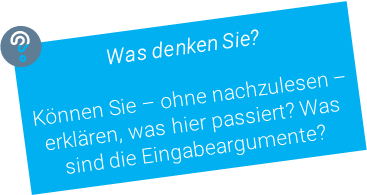

<div>
    <img src=attachment:36c1c4b5-8b03-40e7-b70e-2954939db5d7.png width=200>
</div>
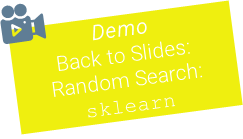

In [32]:
# Inspecting our results
results = pd.DataFrame(regressor.cv_results_)
columns = ['param_min_samples_leaf', 'param_min_impurity_decrease', 'param_max_depth', 'param_ccp_alpha', 
           'mean_test_score', 'std_test_score', 'rank_test_score']
results[columns].sort_values('mean_test_score', ascending=False)

,param_min_samples_leaf,param_min_impurity_decrease,param_max_depth,param_ccp_alpha,mean_test_score,std_test_score,rank_test_score
157,1,0.6,33,0.600,-16.603032,0.162151,1
29,21,0.6,12,0.225,-16.658951,0.180090,2
3,11,0.6,24,0.975,-16.720164,0.158519,3
230,21,0.4,21,1.100,-16.790128,0.176037,4
173,21,0.5,9,1.000,-16.792432,0.162000,5
...,...,...,...,...,...,...,...
179,81,12.8,3,0.775,-18.905214,0.344905,296
67,11,13.4,3,1.200,-18.905348,0.340664,297
253,51,13.5,3,1.750,-18.905359,0.340649,298
63,31,14.1,3,0.625,-18.906829,0.337032,299


### Final Model
Die beste Parameterkombination ist in obigem DataFrame in der ersten Zeile zu finden. Wir könnten nun diese Parameterwerte manuell in unser Modell eingeben.

Bemerkung: der Random-Search wählt aus unserer großen Anzahl an Parameterkombinationen zufällig 300 aus, daher haben wir pro Ausführung unterschiedliche Ergebnisse. Die besten Werte, die ich bisher gefunden habe sind in der unteren Cell _hard-coded_ eingetragen.

In [33]:
# Train with best parameters
rf_best = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42,
                           min_samples_leaf=21, min_impurity_decrease=0.0, 
                           max_depth=24, ccp_alpha=0.1)
rf_best.fit(X_train, y_train)

# predict and evaluate
print(rf_best.score(X_train, y_train))
print(rf_best.score(X_test, y_test))

0.871127805171531
0.7505362951329257


oder wir geben - ganz elegant - die besten Parameter aus dem `RandomizedSearchCV` Regressor ein, das in diesem nach dem Training als Dictionary vorliegt.  

In [34]:
regressor.best_params_

{'min_samples_leaf': 1,
 'min_impurity_decrease': np.float64(0.6),
 'max_depth': 33,
 'ccp_alpha': np.float64(0.6)}

In [35]:
# Train with best parameters
rf = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42)
rf.set_params(**regressor.best_params_)
rf.fit(X_train, y_train)

# predict and evaluate
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.8549618570809593
0.741297147198642


In [32]:
# Or just get the best model
rf = regressor.best_estimator_
rf.fit(X_train, y_train)

# predict and evaluate
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.8622434111310748
0.7450175277320337


In [33]:
# Train with best parameters
rf = RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42)
rf.fit(X_train, y_train)

# predict and evaluate
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9787661901585051
0.7413439613827657


<div>
    <img src=attachment:2a6a0893-a1d9-4e24-a23c-f142b80a6f1b.png width=300>
</div>
Im Vergleich mit unserem Default Random Forest...
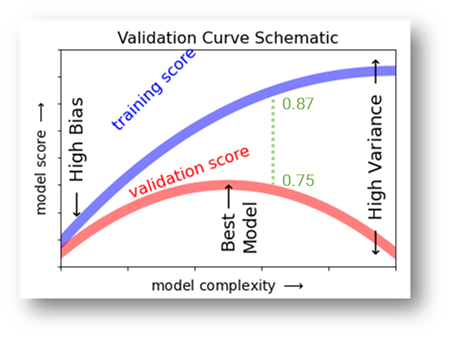

<div>
    <img src=attachment:82a7bbee-4fef-496e-a068-44ae966b7156.png width=300>
</div>
...und unserem linearen Modell...
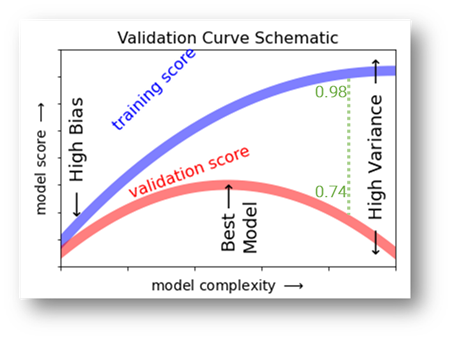

In [34]:
# Evaluate: R**2
print(f'Train set: {lin_reg_model.score(X_train, y_train)}')
print(f'Test set: {lin_reg_model.score(X_test, y_test)}')

Train set: 0.7736110804777454
Test set: 0.7092939799791175


...konnten wir eine prozentuale Steigerung der Genauigkeit um 5.8% erreichen.

In [35]:
(rf_best.score(X_test, y_test) - lin_reg_model.score(X_test, y_test)) / lin_reg_model.score(X_test, y_test) * 100

5.814558746857332

## Ausblick
Jetzt haben wir einen Regressor gefunden, der ein einfaches Baseline Model übertrifft. Jedoch mussten wir hierfür schon ordentlich in die Trickkiste greifen (Data Clipping), damit wir nicht im "unterirdischen" Bereich bzgl. der Vorhersagegenauigkeit landen (probieren Sie es selbst mal aus, wie unser Modell ohne das Clipping abschneidet - evtl. als Aufgabe stellen). Was könnten wir hier noch tun?Deep Learning Ansätze hätten z.B. hier Potential, dass wir die gesamten Rohdaten in ein Modell eingeben könnten.

# Quellen

<div>
    <img src=attachment:1a64c686-98e8-4955-a5d7-826ccb82c66b.png width=80>
</div>
<div>Icons made by <a href="https://www.freepik.com" title="Freepik">Freepik</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>

<div>
    <img src=attachment:ccbabcbf-e606-4d82-8cdb-53e5f69a56d8.png width=80>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/ultimatearm" title="ultimatearm">ultimatearm</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
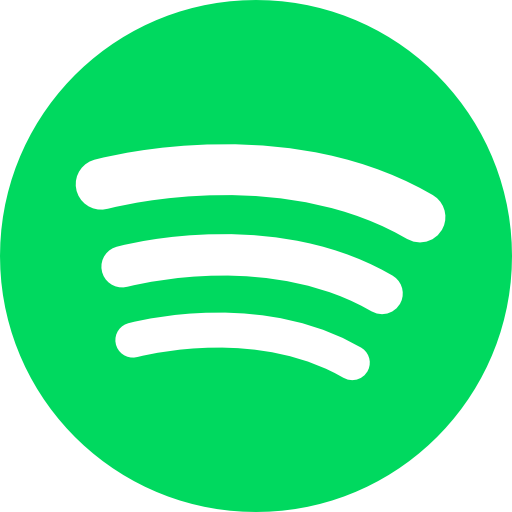
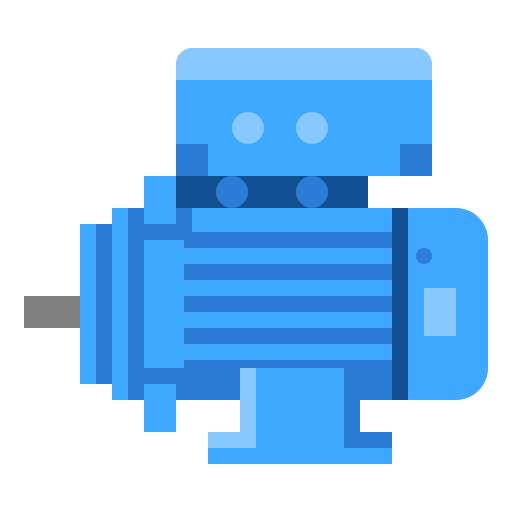

<div>
    <img src=attachment:0857490e-7c5f-43e8-99ed-804f9bd0d479.png width=100>
</div>
<div>Icons made by <a href="https://www.freepik.com" title="Freepik">Freepik</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
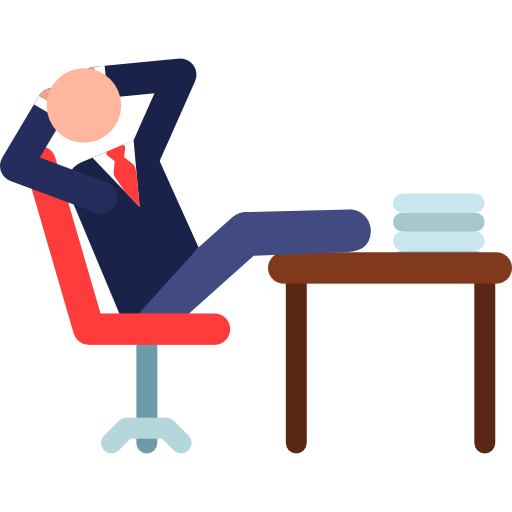